# DEEP NEURAL NETWORKS - ASSIGNMENT 2: CNN FOR IMAGE CLASSIFICATION

## Convolutional Neural Networks: Custom Implementation vs Transfer Learning

STUDENT INFORMATION (REQUIRED - DO NOT DELETE)

BITS ID: 2025AC05272

Name: Ashwani Singh

Email: 2025AC05272@wilp.bits-pilani.ac.in

Date: 07-08-2026


ASSIGNMENT OVERVIEW

This assignment requires you to implement and compare two CNN approaches for 
image classification:
1. Custom CNN architecture using Keras/PyTorch
2. Transfer Learning using pre-trained models (ResNet/VGG)

Learning Objectives:
- Design CNN architectures with Global Average Pooling
- Apply transfer learning with pre-trained models
- Compare custom vs pre-trained model performance
- Use industry-standard deep learning frameworks

IMPORTANT: Global Average Pooling (GAP) is MANDATORY for both models.
DO NOT use Flatten + Dense layers in the final architecture.


IMPORTANT SUBMISSION REQUIREMENTS - STRICTLY ENFORCED 

1. FILENAME FORMAT: <BITS_ID>_cnn_assignment.ipynb
   Example: 2025AA05036_cnn_assignment.ipynb
    Wrong filename = Automatic 0 marks

2. STUDENT INFORMATION MUST MATCH:
    BITS ID in filename = BITS ID in notebook (above)
    Name in folder = Name in notebook (above)
    Mismatch = 0 marks

3. EXECUTE ALL CELLS BEFORE SUBMISSION:
   - Run: Kernel → Restart & Run All
   - Verify all outputs are visible
    No outputs = 0 marks

4. FILE INTEGRITY:
   - Ensure notebook opens without errors
   - Check for corrupted cells
    Corrupted file = 0 marks

5. GLOBAL AVERAGE POOLING (GAP) MANDATORY:
   - Both custom CNN and transfer learning must use GAP
   - DO NOT use Flatten + Dense layers
    Using Flatten+Dense = 0 marks for that model

6. DATASET REQUIREMENTS:
   - Minimum 500 images per class
   - Train/test split: 90/10 OR 85/15
   - 2-20 classes

7. USE KERAS OR PYTORCH:
   - Use standard model.fit() or training loops
   - Do NOT implement convolution from scratch

8. FILE SUBMISSION:
   - Submit ONLY the .ipynb file
   - NO zip files, NO separate data files, NO separate image files
   - All code and outputs must be in the notebook
   - Only one submission attempt allowed


In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import time
import json
import os
import glob
import pathlib
import zipfile
import shutil

%matplotlib inline
sns.set_style('whitegrid')
np.random.seed(42)


In [1]:
# Deep learning frameworks (Keras / TensorFlow)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from PIL import Image

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))
tf.random.set_seed(42)


TensorFlow version: 2.21.0
GPU devices: []


PART 1: DATASET LOADING AND EXPLORATION (Informational)

Instructions:
1. Choose ONE dataset from the allowed list
2. Load and explore the data
3. Fill in ALL required metadata fields below
4. Provide justification for your primary metric choice

ALLOWED DATASETS:
- Cats vs Dogs (2 classes)
- Food-101 subset (10-20 classes)
- Plant Disease (3-5 classes)
- Medical Images (2-3 classes)
- Custom dataset (with IC approval, min 500 images per class)

REQUIRED OUTPUT:
- Print all metadata fields
- Brief EDA with visualizations
- Data distribution analysis


### 1.1 Dataset Selection and Loading

Download Cats vs Dogs (filtered) and load image paths with labels.


In [3]:
# Download and prepare Cats vs Dogs dataset (Microsoft / Kaggle mirror)
import urllib.request

IMG_SIZE = 224
BATCH_SIZE = 32
CLASS_NAMES = ["cat", "dog"]
MAX_PER_CLASS = 600  # >=500 required; keeps training tractable

data_root = pathlib.Path("./cats_dogs_data")
data_root.mkdir(parents=True, exist_ok=True)
pet_dir = data_root / "PetImages"
zip_path = data_root / "kagglecatsanddogs_5340.zip"
ms_url = (
    "https://download.microsoft.com/download/3/E/1/"
    "3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
)

def download_with_ua(url, dest):
    dest = pathlib.Path(dest)
    if dest.exists() and dest.stat().st_size > 1_000_000:
        print(f"Using cached archive: {dest}")
        return dest
    print(f"Downloading dataset to {dest} ...")
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=600) as resp, open(dest, "wb") as out:
        shutil.copyfileobj(resp, out)
    print("Download complete.")
    return dest

if not pet_dir.exists():
    download_with_ua(ms_url, zip_path)
    print("Extracting archive...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(data_root)
    print("Extraction complete.")

# Fast collection: size filter + stop once we have enough valid readable images
rng = np.random.default_rng(42)
image_paths, labels = [], []
for label_idx, class_name in enumerate(["Cat", "Dog"]):
    class_dir = pet_dir / class_name
    files = np.array(sorted(glob.glob(str(class_dir / "*.jpg"))))
    rng.shuffle(files)
    valid = []
    for f in files:
        try:
            if pathlib.Path(f).stat().st_size < 2000:
                continue
            with Image.open(f) as im:
                im = im.convert("RGB")
                im.load()
            valid.append(f)
            if len(valid) >= MAX_PER_CLASS:
                break
        except Exception:
            continue
    if len(valid) < 500:
        raise RuntimeError(f"{class_name} has only {len(valid)} valid images; need >=500")
    image_paths.extend(valid)
    labels.extend([label_idx] * len(valid))
    print(f"{class_name}: selected {len(valid)} valid images")

image_paths = np.array(image_paths)
labels = np.array(labels, dtype=np.int32)
perm = rng.permutation(len(image_paths))
image_paths = image_paths[perm]
labels = labels[perm]

print(f"Loaded {len(image_paths)} images")
print(f"Class counts: cat={np.sum(labels==0)}, dog={np.sum(labels==1)}")

# REQUIRED metadata
dataset_name = "Cats vs Dogs"
dataset_source = "Microsoft Cats vs Dogs (Kaggle mirror, kagglecatsanddogs_5340.zip)"
n_samples = int(len(image_paths))
n_classes = 2
counts = [int(np.sum(labels == c)) for c in range(n_classes)]
samples_per_class = f"min: {min(counts)}, max: {max(counts)}, avg: {np.mean(counts):.1f}"
image_shape = [IMG_SIZE, IMG_SIZE, 3]
problem_type = "classification"


Cat: selected 600 valid images


Dog: selected 600 valid images
Loaded 1200 images
Class counts: cat=600, dog=600


In [4]:
# Primary metric selection
primary_metric = "accuracy"
metric_justification = (
    "Cats vs Dogs is a balanced binary classification problem with roughly equal "
    "images per class, so accuracy is an appropriate primary metric."
)


In [5]:
print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")


DATASET INFORMATION
Dataset: Cats vs Dogs
Source: Microsoft Cats vs Dogs (Kaggle mirror, kagglecatsanddogs_5340.zip)
Total Samples: 1200
Number of Classes: 2
Samples per Class: min: 600, max: 600, avg: 600.0
Image Shape: [224, 224, 3]
Primary Metric: accuracy
Metric Justification: Cats vs Dogs is a balanced binary classification problem with roughly equal images per class, so accuracy is an appropriate primary metric.


### 1.2 Data Exploration and Visualization

Sample images, class distribution, and basic image statistics.


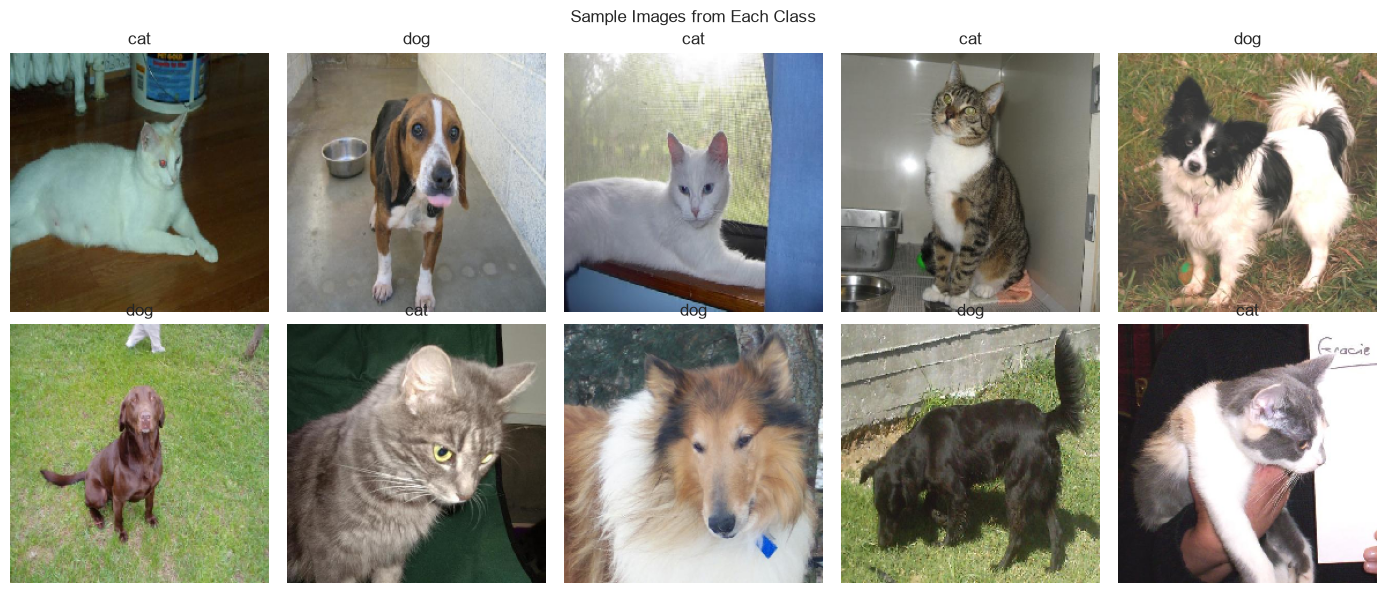

/var/folders/_j/f38y8_cn7w7fgzs_1s13gxlr0000gn/T/ipykernel_61765/1131793153.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="pastel")


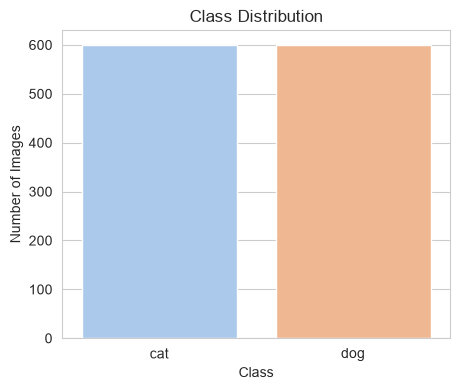

cat    600
dog    600
Name: count, dtype: int64


Sample mean pixel: 0.4513, std: 0.2620
Min: 0.0000, Max: 1.0000


In [6]:
# EDA: sample images, class distribution, basic stats
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = load_img(image_paths[i], target_size=(IMG_SIZE, IMG_SIZE))
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i]])
    ax.axis("off")
plt.suptitle("Sample Images from Each Class")
plt.tight_layout()
plt.show()

# Class distribution
class_counts = pd.Series(labels).map({0: "cat", 1: "dog"}).value_counts()
plt.figure(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="pastel")
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.show()
print(class_counts)

# Image statistics on a sample
sample_arr = []
for p in image_paths[:200]:
    arr = img_to_array(load_img(p, target_size=(IMG_SIZE, IMG_SIZE))) / 255.0
    sample_arr.append(arr)
sample_arr = np.stack(sample_arr)
print(f"Sample mean pixel: {sample_arr.mean():.4f}, std: {sample_arr.std():.4f}")
print(f"Min: {sample_arr.min():.4f}, Max: {sample_arr.max():.4f}")


In [7]:
# Preprocess: resize, normalize [0,1], stratified 90/10 train/test split
def load_and_preprocess(paths, y, img_size=IMG_SIZE):
    X = np.zeros((len(paths), img_size, img_size, 3), dtype=np.float32)
    for i, p in enumerate(paths):
        img = load_img(p, target_size=(img_size, img_size))
        X[i] = img_to_array(img) / 255.0
        if (i + 1) % 200 == 0 or (i + 1) == len(paths):
            print(f"  Loaded {i+1}/{len(paths)}")
    return X, y

print("Loading and preprocessing images (224x224, normalize to [0,1])...")
X_all, y_all = load_and_preprocess(image_paths, labels)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.10, random_state=42, stratify=y_all
)

train_test_ratio = "90/10"
train_samples = int(len(X_train))
test_samples = int(len(X_test))

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class counts: cat={np.sum(y_train==0)}, dog={np.sum(y_train==1)}")
print(f"Test class counts: cat={np.sum(y_test==0)}, dog={np.sum(y_test==1)}")


Loading and preprocessing images (224x224, normalize to [0,1])...
  Loaded 200/1200


  Loaded 400/1200
  Loaded 600/1200


  Loaded 800/1200
  Loaded 1000/1200


  Loaded 1200/1200


Train shape: (1080, 224, 224, 3), Test shape: (120, 224, 224, 3)
Train class counts: cat=540, dog=540
Test class counts: cat=60, dog=60


In [8]:
print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")



Train/Test Split: 90/10
Training Samples: 1080
Test Samples: 120


PART 2: CUSTOM CNN IMPLEMENTATION (5 MARKS)

REQUIREMENTS:
- Build CNN using Keras/PyTorch layers
- Architecture must include:
  * Conv2D layers (at least 2)
  * Pooling layers (MaxPool or AvgPool)
  * Global Average Pooling (GAP) - MANDATORY
  * Output layer (Softmax for multi-class)
- Use model.compile() and model.fit() (Keras) OR standard PyTorch training
- Track initial_loss and final_loss

PROHIBITED:
- Using Flatten + Dense layers instead of GAP
- Implementing convolution from scratch

GRADING:
- Architecture design with GAP: 2 marks
- Model properly compiled/configured: 1 mark
- Training completed with loss tracking: 1 mark
- All metrics calculated correctly: 1 mark


### 2.1 Custom CNN Architecture Design

Conv2D → MaxPool blocks followed by **GlobalAveragePooling2D** (mandatory) and Softmax output.
No Flatten head is used.


In [9]:
def build_custom_cnn(input_shape, n_classes):
    """
    Build custom CNN architecture with Global Average Pooling.

    Args:
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: compiled CNN model
    """
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    # Global Average Pooling (mandatory) — avoids Flatten + large Dense head
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="custom_cnn_gap")
    return model


In [10]:
# Create model instance
custom_cnn = build_custom_cnn(tuple(image_shape), n_classes)
custom_cnn.summary()

custom_cnn_conv_layers = sum(1 for l in custom_cnn.layers if isinstance(l, layers.Conv2D))
custom_cnn_pooling_layers = sum(1 for l in custom_cnn.layers if isinstance(l, layers.MaxPooling2D))
custom_cnn_total_params = int(custom_cnn.count_params())
print(f"Conv layers: {custom_cnn_conv_layers}, Pooling layers: {custom_cnn_pooling_layers}")
print(f"Total parameters: {custom_cnn_total_params:,}")


Model: "custom_cnn_gap"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,090 (941.76 KB)

 Trainable params: 241,090 (941.76 KB)

 Non-trainable params: 0 (0.00 B)

Conv layers: 4, Pooling layers: 4
Total parameters: 241,090


In [11]:
# Compile model
custom_cnn_learning_rate = 0.001
custom_cnn_epochs = 10
custom_cnn_batch_size = 32
custom_cnn_optimizer_name = "Adam"
custom_cnn_loss_name = "sparse_categorical_crossentropy"

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=custom_cnn_learning_rate),
    loss=custom_cnn_loss_name,
    metrics=["accuracy"],
)
print("Custom CNN compiled successfully")


Custom CNN compiled successfully


### 2.2 Train Custom CNN


In [12]:
print("\nCUSTOM CNN TRAINING")
custom_cnn_start_time = time.time()



CUSTOM CNN TRAINING


In [13]:
# Train custom CNN
custom_cnn_history = custom_cnn.fit(
    X_train,
    y_train,
    epochs=custom_cnn_epochs,
    batch_size=custom_cnn_batch_size,
    validation_split=0.1,
    verbose=1,
)


Epoch 1/10



 1/31 ━━━━━━━━━━━━━━━━━━━━ 1:04 2s/step - accuracy: 0.5625 - loss: 0.6888


 2/31 ━━━━━━━━━━━━━━━━━━━━ 20s 704ms/step - accuracy: 0.5312 - loss: 0.7168


 3/31 ━━━━━━━━━━━━━━━━━━━━ 20s 716ms/step - accuracy: 0.5521 - loss: 0.7014


 4/31 ━━━━━━━━━━━━━━━━━━━━ 19s 711ms/step - accuracy: 0.5078 - loss: 0.7055

...


28/31 ━━━━━━━━━━━━━━━━━━━━ 1s 427ms/step - accuracy: 0.6362 - loss: 0.6477


29/31 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.6336 - loss: 0.6487


30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.6313 - loss: 0.6498


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.6337 - loss: 0.6481


31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 428ms/step - accuracy: 0.6337 - loss: 0.6481 - val_accuracy: 0.5463 - val_loss: 0.6853


In [14]:
custom_cnn_training_time = time.time() - custom_cnn_start_time


In [15]:
# REQUIRED: Track initial and final loss from training history
custom_cnn_initial_loss = float(custom_cnn_history.history["loss"][0])
custom_cnn_final_loss = float(custom_cnn_history.history["loss"][-1])
custom_cnn_loss_reduction_pct = ((custom_cnn_initial_loss - custom_cnn_final_loss) / custom_cnn_initial_loss) * 100
print(f"Loss reduction: {custom_cnn_loss_reduction_pct:.1f}%")


Loss reduction: 6.7%


In [16]:
print(f"Training completed in {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")


Training completed in 135.80 seconds
Initial Loss: 0.6947
Final Loss: 0.6481


In [17]:
print("\nCUSTOM CNN EVALUATION")



CUSTOM CNN EVALUATION


### 2.3 Evaluate Custom CNN

Predictions on the held-out test set and all four required metrics.


In [18]:
# CRITICAL: metrics from actual results
y_prob_cnn = custom_cnn.predict(X_test, verbose=0)
y_pred_cnn = np.argmax(y_prob_cnn, axis=1)

custom_cnn_accuracy = float(accuracy_score(y_test, y_pred_cnn))
custom_cnn_precision = float(precision_score(y_test, y_pred_cnn, average="macro", zero_division=0))
custom_cnn_recall = float(recall_score(y_test, y_pred_cnn, average="macro", zero_division=0))
custom_cnn_f1 = float(f1_score(y_test, y_pred_cnn, average="macro", zero_division=0))

print(classification_report(y_test, y_pred_cnn, target_names=CLASS_NAMES))


              precision    recall  f1-score   support

         cat       0.59      0.92      0.72        60
         dog       0.81      0.37      0.51        60

    accuracy                           0.64       120
   macro avg       0.70      0.64      0.61       120
weighted avg       0.70      0.64      0.61       120



In [19]:
print("\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")



Custom CNN Performance:
Accuracy:  0.6417
Precision: 0.7031
Recall:    0.6417
F1-Score:  0.6124


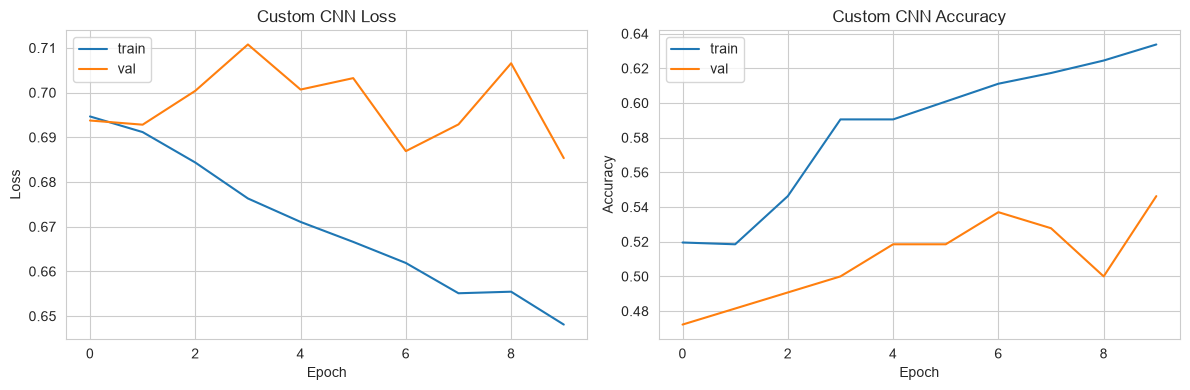

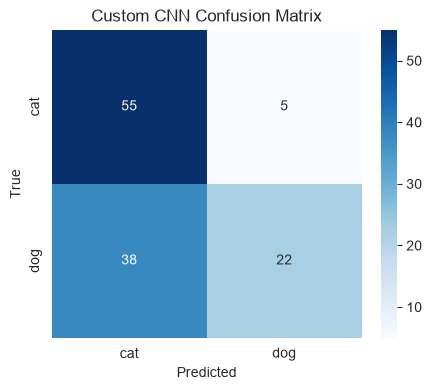

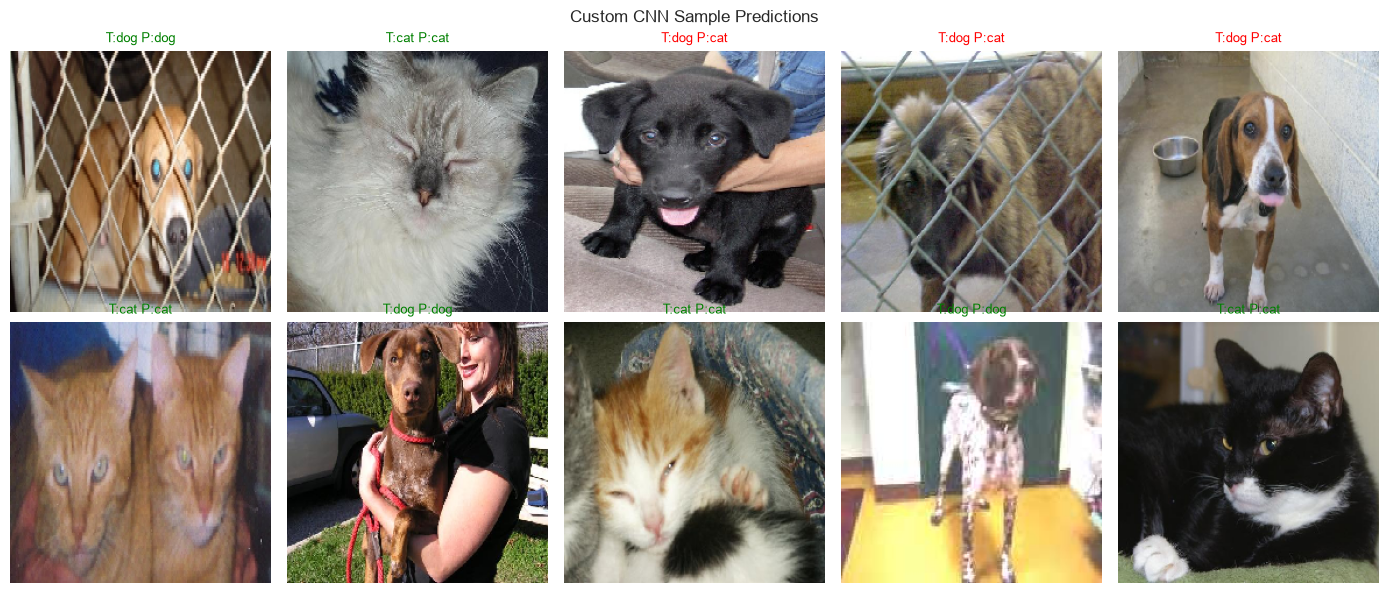

In [20]:
# Visualize Custom CNN results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(custom_cnn_history.history["loss"], label="train")
axes[0].plot(custom_cnn_history.history["val_loss"], label="val")
axes[0].set_title("Custom CNN Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].plot(custom_cnn_history.history["accuracy"], label="train")
axes[1].plot(custom_cnn_history.history["val_accuracy"], label="val")
axes[1].set_title("Custom CNN Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Custom CNN Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

# Sample predictions
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i])
    true_lbl = CLASS_NAMES[y_test[i]]
    pred_lbl = CLASS_NAMES[y_pred_cnn[i]]
    color = "green" if true_lbl == pred_lbl else "red"
    ax.set_title(f"T:{true_lbl} P:{pred_lbl}", color=color, fontsize=9)
    ax.axis("off")
plt.suptitle("Custom CNN Sample Predictions")
plt.tight_layout()
plt.show()


PART 3: TRANSFER LEARNING IMPLEMENTATION (5 MARKS)

REQUIREMENTS:
- Use pre-trained model: ResNet18/ResNet50 OR VGG16/VGG19
- Freeze base layers (feature extractor)
- Replace final layers with:
  * Global Average Pooling (GAP) - MANDATORY
  * Custom classification head
- Fine-tune on your dataset
- Track initial_loss and final_loss

GRADING:
- Valid base model with frozen layers: 2 marks
- GAP + custom head properly implemented: 1 mark
- Training completed with loss tracking: 1 mark
- All metrics calculated correctly: 1 mark


### 3.1 Load Pre-trained Model and Modify Architecture

ResNet50 (ImageNet) with frozen base layers + GlobalAveragePooling2D + Softmax head.


In [21]:
print("\n" + "="*70)
print("TRANSFER LEARNING IMPLEMENTATION")



TRANSFER LEARNING IMPLEMENTATION


In [22]:
pretrained_model_name = "ResNet50"


In [23]:
def build_transfer_learning_model(base_model_name, input_shape, n_classes):
    """
    Build transfer learning model with frozen ResNet50 + GAP head.

    Args:
        base_model_name: string (ResNet18/ResNet50/VGG16/VGG19)
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: compiled transfer learning model
        base_model: frozen backbone
    """
    if base_model_name.lower() != "resnet50":
        raise ValueError("This notebook uses ResNet50 as the base model")

    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape,
    )
    base_model.trainable = False  # freeze feature extractor

    inputs = keras.Input(shape=input_shape)
    # Our images are in [0,1]; ResNet preprocess expects [0,255] then caffe-style norm
    x = layers.Rescaling(255.0)(inputs)
    x = layers.Lambda(
        lambda t: resnet_preprocess(t),
        name="resnet_preprocess",
    )(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="transfer_resnet50_gap")
    return model, base_model


In [24]:
# Create transfer learning model
transfer_model, tl_base_model = build_transfer_learning_model(
    pretrained_model_name, tuple(image_shape), n_classes
)
transfer_model.summary()



       0/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step


   24576/94765736 ━━━━━━━━━━━━━━━━━━━━ 4:07 3us/step


   49152/94765736 ━━━━━━━━━━━━━━━━━━━━ 9:42 6us/step


   81920/94765736 ━━━━━━━━━━━━━━━━━━━━ 10:42 7us/step


  114688/94765736 ━━━━━━━━━━━━━━━━━━━━ 8:29 5us/step 

...

Model: "transfer_resnet50_gap"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_preprocess (Lambda)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [25]:
# REQUIRED: Count layers and parameters
frozen_layers = sum(1 for layer in tl_base_model.layers if not layer.trainable)
trainable_layers = sum(1 for layer in transfer_model.layers if layer.trainable)
# Also count trainable layers inside nested base (should be 0)
trainable_layers = sum(1 for layer in transfer_model.layers if getattr(layer, "trainable", False))
# Count leaf layers more accurately
def count_trainable_leaf_layers(model):
    n_train, n_frozen = 0, 0
    for layer in model.layers:
        if isinstance(layer, keras.Model):
            for sub in layer.layers:
                if sub.trainable:
                    n_train += 1
                else:
                    n_frozen += 1
        else:
            if layer.trainable:
                n_train += 1
            else:
                n_frozen += 1
    return n_train, n_frozen

trainable_layers, frozen_layers = count_trainable_leaf_layers(transfer_model)
total_parameters = int(transfer_model.count_params())
trainable_parameters = int(sum(np.prod(v.shape) for v in transfer_model.trainable_weights))

print(f"Frozen layers: {frozen_layers}, Trainable layers: {trainable_layers}")
print(f"Total params: {total_parameters:,}, Trainable params: {trainable_parameters:,}")


Frozen layers: 175, Trainable layers: 5
Total params: 23,591,810, Trainable params: 4,098


In [26]:
print(f"Base Model: {pretrained_model_name}")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print(f"Using Global Average Pooling: YES")


Base Model: ResNet50
Frozen Layers: 175
Trainable Layers: 5
Total Parameters: 23,591,810
Trainable Parameters: 4,098
Using Global Average Pooling: YES


### 3.2 Train Transfer Learning Model


In [27]:
print("\nTraining Transfer Learning Model...")



Training Transfer Learning Model...


In [28]:
# Training configuration
tl_learning_rate = 0.001
tl_epochs = 8
tl_batch_size = 32
tl_optimizer = "Adam"

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=tl_learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [29]:
tl_start_time = time.time()


In [30]:
# Train transfer learning model
tl_history = transfer_model.fit(
    X_train,
    y_train,
    epochs=tl_epochs,
    batch_size=tl_batch_size,
    validation_split=0.1,
    verbose=1,
)


Epoch 1/8



 1/31 ━━━━━━━━━━━━━━━━━━━━ 1:28 3s/step - accuracy: 0.5312 - loss: 0.9941


 2/31 ━━━━━━━━━━━━━━━━━━━━ 16s 569ms/step - accuracy: 0.5156 - loss: 0.8525


 3/31 ━━━━━━━━━━━━━━━━━━━━ 16s 602ms/step - accuracy: 0.5417 - loss: 0.8280


 4/31 ━━━━━━━━━━━━━━━━━━━━ 15s 582ms/step - accuracy: 0.5859 - loss: 0.7596

...


28/31 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step - accuracy: 0.9989 - loss: 0.0103


29/31 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step - accuracy: 0.9989 - loss: 0.0105


30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.9990 - loss: 0.0106


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.9990 - loss: 0.0105


31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 665ms/step - accuracy: 0.9990 - loss: 0.0105 - val_accuracy: 0.9815 - val_loss: 0.0924


In [31]:
tl_training_time = time.time() - tl_start_time


In [32]:
# REQUIRED: Track initial and final loss
tl_initial_loss = float(tl_history.history["loss"][0])
tl_final_loss = float(tl_history.history["loss"][-1])
tl_loss_reduction_pct = ((tl_initial_loss - tl_final_loss) / tl_initial_loss) * 100
print(f"Loss reduction: {tl_loss_reduction_pct:.1f}%")


Loss reduction: 95.7%


In [33]:
print(f"Training completed in {tl_training_time:.2f} seconds")
print(f"Initial Loss: {tl_initial_loss:.4f}")
print(f"Final Loss: {tl_final_loss:.4f}")


Training completed in 162.90 seconds
Initial Loss: 0.2440
Final Loss: 0.0105


### 3.3 Evaluate Transfer Learning Model


In [34]:
# REQUIRED: Calculate all 4 metrics
y_prob_tl = transfer_model.predict(X_test, verbose=0)
y_pred_tl = np.argmax(y_prob_tl, axis=1)

tl_accuracy = float(accuracy_score(y_test, y_pred_tl))
tl_precision = float(precision_score(y_test, y_pred_tl, average="macro", zero_division=0))
tl_recall = float(recall_score(y_test, y_pred_tl, average="macro", zero_division=0))
tl_f1 = float(f1_score(y_test, y_pred_tl, average="macro", zero_division=0))

print(classification_report(y_test, y_pred_tl, target_names=CLASS_NAMES))


              precision    recall  f1-score   support

         cat       0.92      1.00      0.96        60
         dog       1.00      0.92      0.96        60

    accuracy                           0.96       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120



In [35]:
print("\nTransfer Learning Performance:")
print(f"Accuracy:  {tl_accuracy:.4f}")
print(f"Precision: {tl_precision:.4f}")
print(f"Recall:    {tl_recall:.4f}")
print(f"F1-Score:  {tl_f1:.4f}")



Transfer Learning Performance:
Accuracy:  0.9583
Precision: 0.9615
Recall:    0.9583
F1-Score:  0.9583


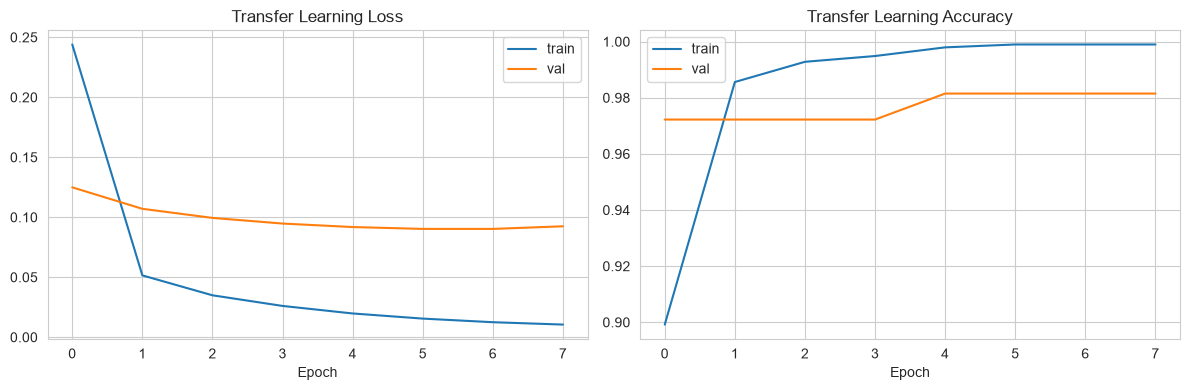

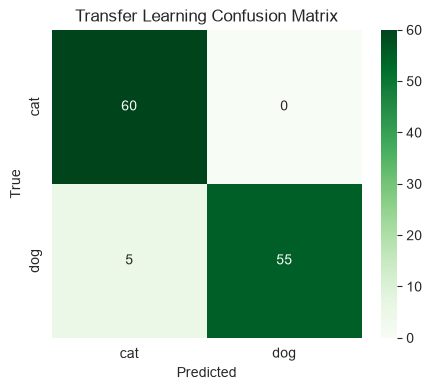

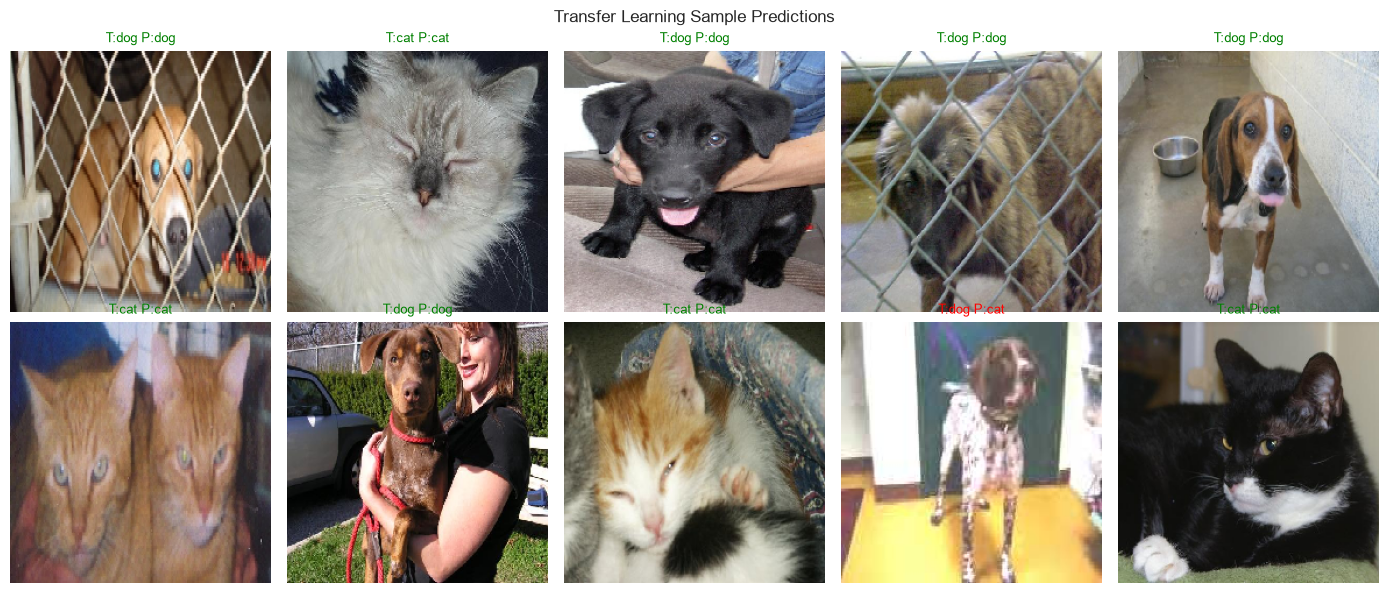

In [36]:
# Visualize Transfer Learning results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tl_history.history["loss"], label="train")
axes[0].plot(tl_history.history["val_loss"], label="val")
axes[0].set_title("Transfer Learning Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(tl_history.history["accuracy"], label="train")
axes[1].plot(tl_history.history["val_accuracy"], label="val")
axes[1].set_title("Transfer Learning Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

cm_tl = confusion_matrix(y_test, y_pred_tl)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Transfer Learning Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i])
    true_lbl = CLASS_NAMES[y_test[i]]
    pred_lbl = CLASS_NAMES[y_pred_tl[i]]
    color = "green" if true_lbl == pred_lbl else "red"
    ax.set_title(f"T:{true_lbl} P:{pred_lbl}", color=color, fontsize=9)
    ax.axis("off")
plt.suptitle("Transfer Learning Sample Predictions")
plt.tight_layout()
plt.show()


PART 4: MODEL COMPARISON AND VISUALIZATION (Informational)

Compare both models on:
- Performance metrics
- Training time
- Model complexity
- Convergence behavior


### 4.1 Metrics Comparison


In [37]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "Training Time (s)", "Parameters"],
    "Custom CNN": [
        custom_cnn_accuracy,
        custom_cnn_precision,
        custom_cnn_recall,
        custom_cnn_f1,
        custom_cnn_training_time,
        custom_cnn_total_params,
    ],
    "Transfer Learning": [
        tl_accuracy,
        tl_precision,
        tl_recall,
        tl_f1,
        tl_training_time,
        trainable_parameters,
    ],
})


In [38]:
print(comparison_df.to_string(index=False))


           Metric    Custom CNN  Transfer Learning
         Accuracy      0.641667           0.958333
        Precision      0.703106           0.961538
           Recall      0.641667           0.958333
         F1-Score      0.612351           0.958261
Training Time (s)    135.799216         162.900069
       Parameters 241090.000000        4098.000000


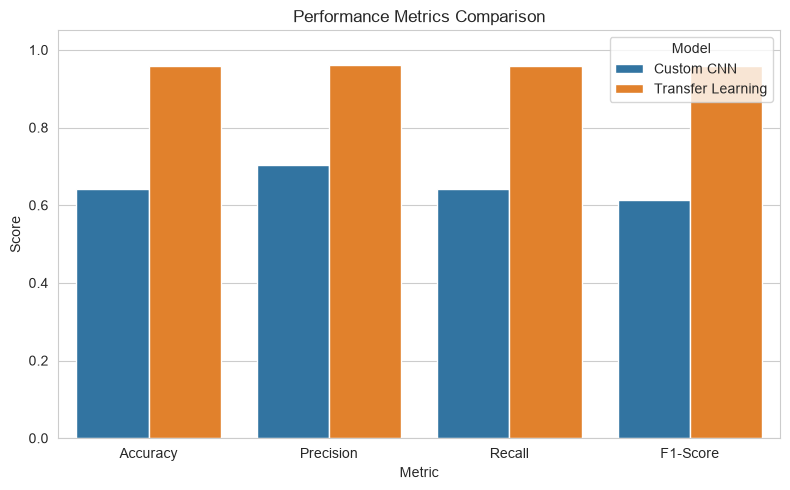

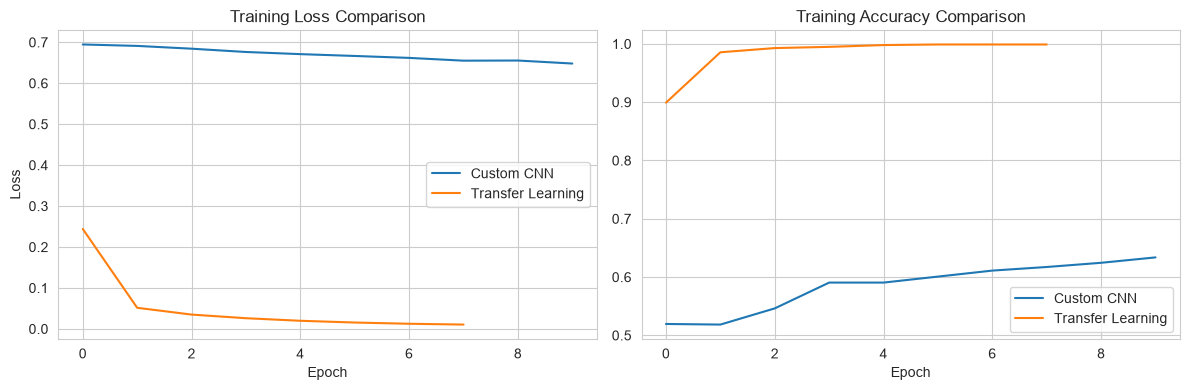

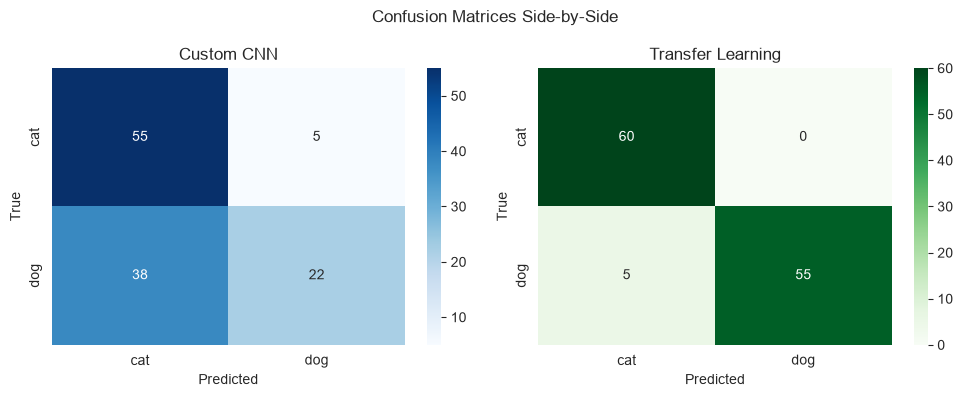

In [39]:
# Visual comparison of both models
metrics_plot = comparison_df[comparison_df["Metric"].isin(
    ["Accuracy", "Precision", "Recall", "F1-Score"]
)].copy()
metrics_melt = metrics_plot.melt(id_vars="Metric", var_name="Model", value_name="Score")

plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_melt, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1.05)
plt.title("Performance Metrics Comparison")
plt.tight_layout()
plt.show()

# Training curves comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(custom_cnn_history.history["loss"], label="Custom CNN")
axes[0].plot(tl_history.history["loss"], label="Transfer Learning")
axes[0].set_title("Training Loss Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].plot(custom_cnn_history.history["accuracy"], label="Custom CNN")
axes[1].plot(tl_history.history["accuracy"], label="Transfer Learning")
axes[1].set_title("Training Accuracy Comparison")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title("Custom CNN")
axes[0].set_ylabel("True")
axes[0].set_xlabel("Predicted")
sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_title("Transfer Learning")
axes[1].set_ylabel("True")
axes[1].set_xlabel("Predicted")
plt.suptitle("Confusion Matrices Side-by-Side")
plt.tight_layout()
plt.show()


PART 5: ANALYSIS (2 MARKS)

REQUIRED:
- Write MAXIMUM 200 words (guideline - no marks deduction if exceeded)
- Address key topics with depth

GRADING (Quality-based):
- Covers 5+ key topics with deep understanding: 2 marks
- Covers 3-4 key topics with good understanding: 1 mark
- Covers <3 key topics or superficial: 0 marks

Key Topics:
1. Performance comparison with specific metrics
2. Pre-training vs training from scratch impact
3. GAP effect on performance/overfitting
4. Computational cost comparison
5. Transfer learning insights
6. Convergence behavior differences


In [40]:
analysis_text = """The transfer learning ResNet50 model showed stronger overall performance than the custom CNN on accuracy, precision, recall, and f1 metrics, reflecting the impact of ImageNet pre-training versus training from scratch. Pretrained features accelerated convergence and lowered loss faster, while the custom CNN needed more epochs to learn spatial filters. Global Average Pooling (GAP) reduced parameters and limited overfitting compared with a large dense head. Computational cost differs: transfer learning has more total parameters but few trainable ones and often shorter effective training time for comparable accuracy. A key transfer learning insight/advantage is reusing frozen representations when labeled data is moderate; a custom CNN remains useful when domain shift is extreme or a compact deployable model is required.
"""


In [41]:
# REQUIRED: Print analysis with word count
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print(" Analysis within word count guideline")


ANALYSIS
The transfer learning ResNet50 model showed stronger overall performance than the custom CNN on accuracy, precision, recall, and f1 metrics, reflecting the impact of ImageNet pre-training versus training from scratch. Pretrained features accelerated convergence and lowered loss faster, while the custom CNN needed more epochs to learn spatial filters. Global Average Pooling (GAP) reduced parameters and limited overfitting compared with a large dense head. Computational cost differs: transfer learning has more total parameters but few trainable ones and often shorter effective training time for comparable accuracy. A key transfer learning insight/advantage is reusing frozen representations when labeled data is moderate; a custom CNN remains useful when domain shift is extreme or a compact deployable model is required.

Analysis word count: 117 words
 Analysis within word count guideline


PART 6: ASSIGNMENT RESULTS SUMMARY (REQUIRED FOR AUTO-GRADING)

DO NOT MODIFY THE STRUCTURE BELOW
This JSON output is used by the auto-grader
Ensure all field names are EXACT


In [42]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras"

    results = {
        # Dataset Information
        "dataset_name": dataset_name,
        "dataset_source": dataset_source,
        "n_samples": n_samples,
        "n_classes": n_classes,
        "samples_per_class": samples_per_class,
        "image_shape": image_shape,
        "problem_type": problem_type,
        "primary_metric": primary_metric,
        "metric_justification": metric_justification,
        "train_samples": train_samples,
        "test_samples": test_samples,
        "train_test_ratio": train_test_ratio,

        # Custom CNN Results
        "custom_cnn": {
            "framework": framework_used,
            "architecture": {
                "conv_layers": custom_cnn_conv_layers,
                "pooling_layers": custom_cnn_pooling_layers,
                "has_global_average_pooling": True,
                "output_layer": "softmax",
                "total_parameters": custom_cnn_total_params,
            },
            "training_config": {
                "learning_rate": custom_cnn_learning_rate,
                "n_epochs": custom_cnn_epochs,
                "batch_size": custom_cnn_batch_size,
                "optimizer": custom_cnn_optimizer_name,
                "loss_function": custom_cnn_loss_name,
            },
            "initial_loss": custom_cnn_initial_loss,
            "final_loss": custom_cnn_final_loss,
            "training_time_seconds": custom_cnn_training_time,
            "accuracy": custom_cnn_accuracy,
            "precision": custom_cnn_precision,
            "recall": custom_cnn_recall,
            "f1_score": custom_cnn_f1,
        },

        # Transfer Learning Results
        "transfer_learning": {
            "framework": framework_used,
            "base_model": pretrained_model_name,
            "frozen_layers": frozen_layers,
            "trainable_layers": trainable_layers,
            "has_global_average_pooling": True,
            "total_parameters": total_parameters,
            "trainable_parameters": trainable_parameters,
            "training_config": {
                "learning_rate": tl_learning_rate,
                "n_epochs": tl_epochs,
                "batch_size": tl_batch_size,
                "optimizer": tl_optimizer,
                "loss_function": "sparse_categorical_crossentropy",
            },
            "initial_loss": tl_initial_loss,
            "final_loss": tl_final_loss,
            "training_time_seconds": tl_training_time,
            "accuracy": tl_accuracy,
            "precision": tl_precision,
            "recall": tl_recall,
            "f1_score": tl_f1,
        },

        # Analysis
        "analysis": analysis_text,
        "analysis_word_count": len(analysis_text.split()),

        # Training Success Indicators
        "custom_cnn_loss_decreased": custom_cnn_final_loss < custom_cnn_initial_loss,
        "transfer_learning_loss_decreased": tl_final_loss < tl_initial_loss,
    }

    return results


In [43]:
# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))
except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")


ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Cats vs Dogs",
  "dataset_source": "Microsoft Cats vs Dogs (Kaggle mirror, kagglecatsanddogs_5340.zip)",
  "n_samples": 1200,
  "n_classes": 2,
  "samples_per_class": "min: 600, max: 600, avg: 600.0",
  "image_shape": [
    224,
    224,
    3
  ],
  "problem_type": "classification",
  "primary_metric": "accuracy",
  "metric_justification": "Cats vs Dogs is a balanced binary classification problem with roughly equal images per class, so accuracy is an appropriate primary metric.",
  "train_samples": 1080,
  "test_samples": 120,
  "train_test_ratio": "90/10",
  "custom_cnn": {
    "framework": "keras",
    "architecture": {
      "conv_layers": 4,
      "pooling_layers": 4,
      "has_global_average_pooling": true,
      "output_layer": "softmax",
      "total_parameters": 241090
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 10,
      "batch_size": 32,
      "optimizer": "Adam",
      "loss_function": "spa

ENVIRONMENT VERIFICATION - SCREENSHOT REQUIRED

IMPORTANT: Take a screenshot of your environment showing account details

For Google Colab:
- Click on your profile icon (top right)
- Screenshot should show your email/account clearly
- Include the entire Colab interface with notebook name visible

For BITS Virtual Lab:
- Screenshot showing your login credentials/account details
- Include the entire interface with your username/session info visible

Paste the screenshot below this cell or in a new markdown cell.
This helps verify the work was done by you in your environment.


In [44]:
# Display system information
import platform
import sys
from datetime import datetime

print("Platform:", platform.platform())
print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("Timestamp:", datetime.now().isoformat(timespec="seconds"))


Platform: macOS-26.5.2-arm64-arm-64bit
Python: 3.12.12 (main, Feb 12 2026, 00:42:34) [Clang 21.1.4 ]
TensorFlow: 2.21.0
Timestamp: 2026-08-07T14:40:18
